# Results — Dataset 1 (Monkeypox, Exploratory)

This notebook reports the experimental results for both research questions on the Monkeypox dataset.

**Dataset:** Monkeypox Misinformation dataset (dataset 1)  
**LLMs evaluated:** GPT, DeepSeek, Gemini  
**Embedding models:** Gemma, BGE-M3, BERTweet  
**BERTScore model:** BERTweet-large  
**Similarity metric:** cosine similarity (primary), BERTScore

In [44]:
import sys
import os
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pyarrow.parquet as pq
from scipy import stats
import krippendorff
from sklearn.metrics import cohen_kappa_score

if Path.cwd().name == "notebooks":
    os.chdir("..")
sys.path.insert(0, "src")

from utils import load_experiment_results, load_human_posts, load_llm_generations

DATASET_NR  = 1
LLM_NAMES   = ["deepseek", "gemini", "gpt"]
EMBEDDING   = "gemma"
SCORER      = "bertweet_large"

M_ALL  = 4567
# M_RETR = 200

K_VALUES = [5, 25, 50, 100, 200, 300, 400]

LABEL_ORDER = ["FALSE", "TRUE", "OTHER"]
PALETTE     = {"FALSE": "#D55E00", "TRUE": "#009E73", "OTHER": "#0072B2"}
LLM_PALETTE = {"deepseek": "#CC79A7", "gemini": "#56B4E9", "gpt": "#008080"}
STYLES      = {
    "Gemma":    ("#4EAFD4", "o", "-"),
    "BERTweet": ("#E8651A", "^", "-"),
    "BGE-M3":   ("#27AE60", "s", "-"),
    "BM25":     ("#555555", "P", "-"),
}

FIGSIZE          = (15, 5.5)
FONTSIZE_TITLE   = 18
FONTSIZE_AXLABEL = 18
FONTSIZE_TICK    = 15
FONTSIZE_LEGEND  = 16
FLIER_SIZE       = 3

In [45]:
human_posts = load_human_posts(DATASET_NR)
human_posts["label"] = human_posts["ternary_class"].map({0: "TRUE", 1: "FALSE", 9: "OTHER"}).fillna("OTHER")

N_HUMAN   = len(human_posts)
N_FALSE   = (human_posts["label"] == "FALSE").sum()
BASE_RATE = N_FALSE / N_HUMAN

print(f"N human posts: {N_HUMAN}")
print(f"Label distribution:\n{human_posts['label'].value_counts()}")
print(f"Base FALSE rate: {BASE_RATE:.3f}")

N human posts: 4567
Label distribution:
label
OTHER    2632
FALSE    1023
TRUE      912
Name: count, dtype: int64
Base FALSE rate: 0.224


## 0. Overview — Post length by source

In [46]:
rows = []
char_len = human_posts["text"].str.len()
word_cnt = human_posts["text"].apply(lambda x: len(str(x).split()))
rows.append({"Model": "Human",
             "Char length": f"{char_len.mean():.1f} ± {char_len.std():.1f}",
             "Word count":  f"{word_cnt.mean():.1f} ± {word_cnt.std():.1f}"})

for llm in LLM_NAMES:
    llm_posts = load_llm_generations(DATASET_NR, llm)
    char_len = llm_posts["generated_text"].str.len()
    word_cnt = llm_posts["generated_text"].apply(lambda x: len(str(x).split()))
    rows.append({"Model": llm,
                 "Char length": f"{char_len.mean():.1f} ± {char_len.std():.1f}",
                 "Word count":  f"{word_cnt.mean():.1f} ± {word_cnt.std():.1f}"})

pd.DataFrame(rows).set_index("Model")

,Char length,Word count
Model,,
Human,145.8 ± 89.6,23.0 ± 14.0
deepseek,167.3 ± 27.6,27.6 ± 4.5
gemini,206.0 ± 37.8,32.2 ± 6.6
gpt,268.4 ± 12.1,42.9 ± 3.4


---
## 1. RQ1 — Semantic Alignment

> **RQ1:** Can LLMs be prompted to generate disinformation content that is semantically similar to human-authored ones?

We measure semantic similarity between each LLM-generated post and all human posts using:
- **Cosine similarity** (Gemma embeddings): sentence-level semantic proximity
- **BERTScore F1** (BERTweet-large): contextual token-level similarity

In [47]:
all_pairs_list = []
for llm in LLM_NAMES:
    pairs_df, _, _ = load_experiment_results(
        dataset_nr=DATASET_NR, llm_name=llm,
        embedding_name=EMBEDDING, scorer_name=SCORER, m=M_ALL
    )
    pairs_df["llm"] = llm
    pairs_df["label"] = pairs_df["human_row_idx"].map(human_posts["label"])
    all_pairs_list.append(pairs_df)

all_pairs = pd.concat(all_pairs_list, ignore_index=True)
print(f"Total pairs: {len(all_pairs)}")
all_pairs.head()

Total pairs: 1370100


,llm_row_idx,human_row_idx,rank_cosine,cosine_score,bertscore_score,rank_bertscore,llm,label
0,0,1599,1,0.697391,0.818418,20,deepseek,OTHER
1,0,3811,2,0.692493,0.807766,169,deepseek,FALSE
2,0,4368,3,0.686701,0.798019,620,deepseek,FALSE
3,0,3779,4,0.684988,0.807322,185,deepseek,FALSE
4,0,1696,5,0.675242,0.805534,237,deepseek,OTHER


In [48]:
def percentile(n):
    def fn(x): return x.quantile(n)
    return fn

summary = (
    all_pairs.groupby("llm")
    .agg(
        n_pairs     = ("bertscore_score", "count"),
        mean_bscore = ("bertscore_score", "mean"),
        std_bscore  = ("bertscore_score", "std"),
        q75_bscore  = ("bertscore_score", percentile(0.75)),
        mean_cosine = ("cosine_score", "mean"),
        std_cosine  = ("cosine_score", "std")
    )
    .round(4)
)
summary

,n_pairs,mean_bscore,std_bscore,q75_bscore,mean_cosine,std_cosine
llm,,,,,,
deepseek,456700,0.7826,0.0223,0.7976,0.3845,0.0833
gemini,456700,0.7759,0.0214,0.7903,0.4521,0.0689
gpt,456700,0.7682,0.0219,0.7832,0.4276,0.0699


### 1.1 Cross-Label Analysis

Are LLM-generated fake posts more similar to human FALSE posts than TRUE or OTHER?

In [49]:
label_summary_per_gen = (
    all_pairs.groupby(["llm", "llm_row_idx", "label"])
    .agg(
        max_bscore  = ("bertscore_score", "max"),
        mean_bscore = ("bertscore_score", "mean"),
        max_cosine  = ("cosine_score", "max"),
        mean_cosine = ("cosine_score", "mean")
    )
    .round(4)
)

summary_table = (
    label_summary_per_gen
    .groupby(["llm", "label"])
    .agg(
        mean_of_max_bscore  = ("max_bscore", "mean"),
        mean_of_max_cosine  = ("max_cosine", "mean"),
        mean_of_mean_cosine = ("mean_cosine", "mean")
    )
    .round(4)
)
summary_table

mean_of_max_bscore  mean_of_max_cosine  mean_of_mean_cosine
llm      label                                                             
deepseek FALSE              0.8318              0.6233               0.4054
         OTHER              0.8373              0.6218               0.3849
         TRUE               0.8230              0.5616               0.3603
gemini   FALSE              0.8245              0.6792               0.4717
         OTHER              0.8281              0.6853               0.4525
         TRUE               0.8195              0.6348               0.4287
gpt      FALSE              0.8136              0.6592               0.4429
         OTHER              0.8211              0.6740               0.4266
         TRUE               0.8131              0.6216               0.4134

### 1.2 Boxplot — Max similarity by label

/var/folders/vj/fm9658bj7wb1s7368mf8l9c40000gn/T/ipykernel_95767/4215151442.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/var/folders/vj/fm9658bj7wb1s7368mf8l9c40000gn/T/ipykernel_95767/4215151442.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/var/folders/vj/fm9658bj7wb1s7368mf8l9c40000gn/T/ipykernel_95767/4215151442.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


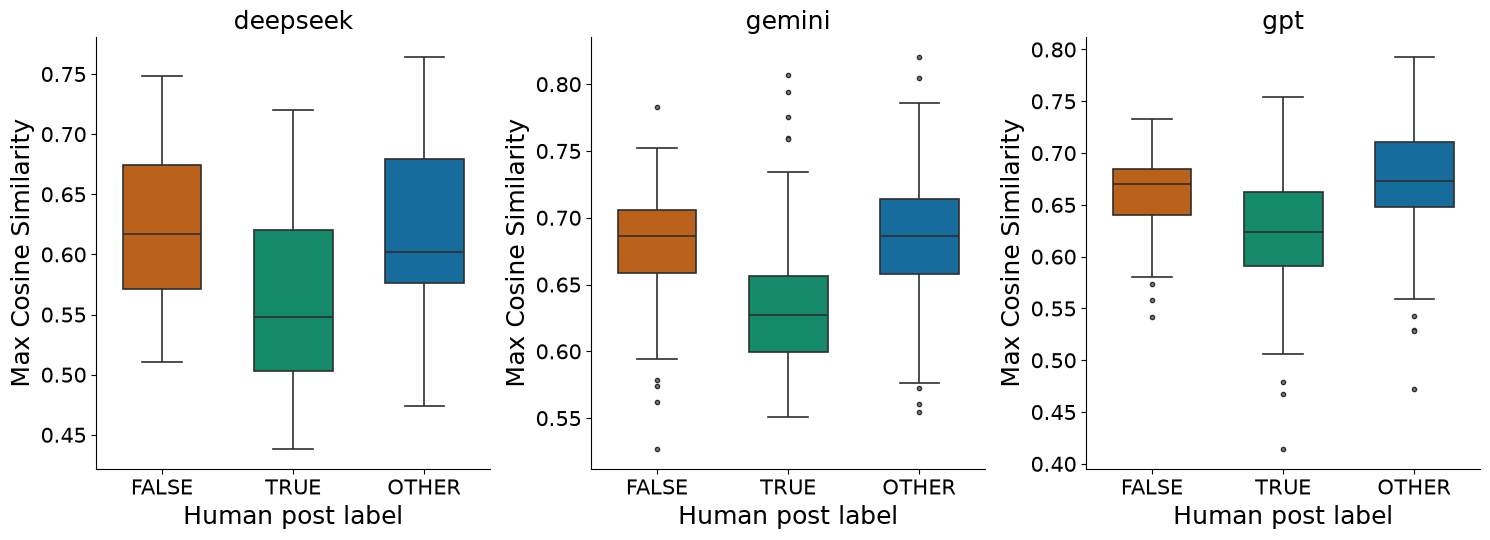

In [50]:
plot_df = label_summary_per_gen.reset_index()

metrics = [
    ("max_cosine", "(a) Max Cosine Similarity"),
    ("max_bscore", "(b) Max BERTScore F1"),
]

fig, axes = plt.subplots(1, len(LLM_NAMES), figsize=FIGSIZE, sharey=False)

for ax, llm in zip(axes, LLM_NAMES):
    data = plot_df[plot_df["llm"] == llm]
    sns.boxplot(
        data=data, x="label", y="max_cosine",
        order=LABEL_ORDER, palette=PALETTE,
        ax=ax, width=0.6, linewidth=1.2,
        flierprops=dict(marker='o', markerfacecolor='gray', markersize=FLIER_SIZE)
    )
    ax.set_title(llm, fontsize=FONTSIZE_TITLE)
    ax.set_xlabel("Human post label", fontsize=FONTSIZE_AXLABEL)
    ax.set_ylabel("Max Cosine Similarity", fontsize=FONTSIZE_AXLABEL)
    ax.tick_params(labelsize=FONTSIZE_TICK)
    sns.despine(ax=ax)

plt.tight_layout()
plt.show()

### 1.3 Alignment Plot — MaxSim(FALSE) − MaxSim(TRUE)

/var/folders/vj/fm9658bj7wb1s7368mf8l9c40000gn/T/ipykernel_95767/1499035710.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/var/folders/vj/fm9658bj7wb1s7368mf8l9c40000gn/T/ipykernel_95767/1499035710.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


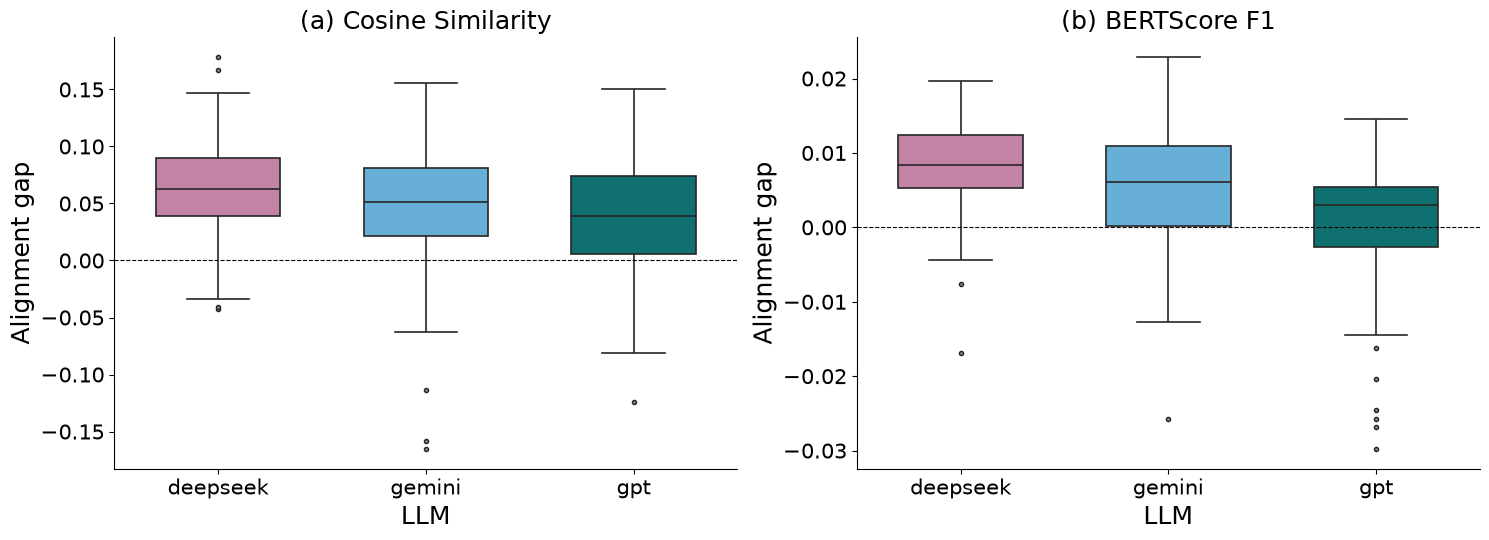

In [51]:
pivot_df = plot_df.pivot(
    index=["llm", "llm_row_idx"], columns="label",
    values=["max_cosine", "max_bscore"]
).reset_index()

pivot_df.columns = [
    f"{metric}_{label}" if label else metric
    for metric, label in pivot_df.columns
]

pivot_df["cosine_gap"] = pivot_df["max_cosine_FALSE"] - pivot_df["max_cosine_TRUE"]
pivot_df["bscore_gap"] = pivot_df["max_bscore_FALSE"] - pivot_df["max_bscore_TRUE"]

metrics = [("cosine_gap", "(a) Cosine Similarity"), ("bscore_gap", "(b) BERTScore F1")]

fig, axes = plt.subplots(1, 2, figsize=FIGSIZE, sharey=False)

for ax, (metric, title) in zip(axes, metrics):
    sns.boxplot(
        data=pivot_df, x="llm", y=metric,
        order=LLM_NAMES, palette=LLM_PALETTE,
        ax=ax, width=0.6, linewidth=1.2,
        flierprops=dict(marker='o', markerfacecolor='gray', markersize=FLIER_SIZE)
    )
    ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
    ax.set_title(title, fontsize=FONTSIZE_TITLE)
    ax.set_xlabel("LLM", fontsize=FONTSIZE_AXLABEL)
    ax.set_ylabel("Alignment gap", fontsize=FONTSIZE_AXLABEL)
    ax.tick_params(labelsize=FONTSIZE_TICK)
    sns.despine(ax=ax)

plt.tight_layout()
plt.show()

### 1.4 Statistical Tests (Wilcoxon Signed-Rank)

In [52]:
from scipy import stats

metrics = [("max_cosine", "Cosine Similarity"), ("max_bscore", "BERTScore F1")]

results = []

for i, llm in enumerate (LLM_NAMES):
    llm_data = label_summary_per_gen.loc[llm]  # index is now (llm_row_idx, label)

    for metric, metric_label in [("max_cosine", "Cosine Similarity"), ("max_bscore", "BERTScore F1")]:
        
        # Extract per-generation scores for each label
        # llm_row_idx is the pairing key — same index = same generation
        false_scores = llm_data.loc[llm_data.index.get_level_values("label") == "FALSE", metric]
        true_scores  = llm_data.loc[llm_data.index.get_level_values("label") == "TRUE",  metric]

        # Align by llm_row_idx to guarantee correct pairing
        false_scores = false_scores.reset_index(level="label", drop=True)
        true_scores  = true_scores.reset_index(level="label", drop=True)
        false_scores, true_scores = false_scores.align(true_scores, join="inner")

        n = len(false_scores)
        stat, p = stats.wilcoxon(
            false_scores.values,
            true_scores.values,
            alternative="greater"  # H1: FALSE > TRUE
        )

        # Effect size as proportion of max possible W
        r = stat / (n * (n + 1) / 2)
        w_plus = stat
        w_total = n * (n + 1) / 2
        w_minus = w_total - w_plus

        r_rb = (w_plus - w_minus) / w_total

        results.append({
            "LLM":           LLM_NAMES[i],
            "Metric":        metric_label,
            "Median FALSE":  round(false_scores.median(), 4),
            "Median TRUE":   round(true_scores.median(), 4),
            "n":             n,
            "W statistic":   stat,
            "p-value":       round(p, 20),
            "Effect size r": round(r_rb, 4),
        })

results_df = pd.DataFrame(results)
print(results_df.to_string(index=False))

     LLM            Metric  Median FALSE  Median TRUE   n  W statistic      p-value  Effect size r
deepseek Cosine Similarity        0.6171       0.5478 100       4947.0 4.123000e-17         0.9592
deepseek      BERTScore F1        0.8310       0.8214 100       4891.0 2.054400e-16         0.9370
  gemini Cosine Similarity        0.6865       0.6269 100       4435.0 2.563415e-11         0.7564
  gemini      BERTScore F1        0.8241       0.8189 100       4158.0 9.834233e-09         0.6467
     gpt Cosine Similarity        0.6706       0.6239 100       4369.0 1.146771e-10         0.7303
     gpt      BERTScore F1        0.8135       0.8118 100       3215.0 8.834285e-03         0.2733


---
## 2. RQ2 — Disinformation Flagging Performance

> **RQ2:** Can synthetic fakes serve as proxies for identifying false social media posts?

The flagging pipeline retrieves the top-k human posts most similar to each LLM-generated fake, then deduplicates. We evaluate label enrichment, precision, recall, and nDCG.

**Baseline:** BM25 keyword retrieval.

In [53]:
GAIN_MAP      = {"FALSE": 1, "TRUE": 0, "OTHER": 0}
NDCG_GAIN_MAP = {"FALSE": 2, "TRUE": 0, "OTHER": 1}

def precision_at_k(df, k):
    top_k = df[df["rank"] <= k]
    return top_k["label"].map(GAIN_MAP).sum() / k

def recall_at_k(df, k):
    top_k = df[df["rank"] <= k]
    tp    = top_k["label"].map(GAIN_MAP).sum()
    total = df["label"].map(GAIN_MAP).sum()
    return tp / total if total > 0 else 0.0

def dcg(gains):
    g = gains.reset_index(drop=True)
    return float((g / np.log2(g.index + 2)).sum())

def ndcg_at_k(df, k):
    top_k_gains = df[df["rank"] <= k]["label"].map(NDCG_GAIN_MAP).reset_index(drop=True)
    ideal_gains = df["label"].map(NDCG_GAIN_MAP).sort_values(ascending=False).head(k).reset_index(drop=True)
    idcg = dcg(ideal_gains)
    return dcg(top_k_gains) / idcg if idcg > 0 else 0.0

def build_bm25_df(bm25_scores, human_posts, llm_posts):
    n_llm, n_human = bm25_scores.shape
    llm_idx   = np.repeat(np.arange(n_llm), n_human)
    human_idx = np.tile(np.arange(n_human), n_llm)
    df = pd.DataFrame({
        "llm_row_idx":   llm_idx,
        "human_row_idx": human_idx,
        "score":         bm25_scores.ravel(),
    })
    df = df.merge(human_posts[["label"]], left_on="human_row_idx", right_index=True, how="left")
    return df

In [54]:
records = []

for llm in LLM_NAMES:
    llm_posts = load_llm_generations(DATASET_NR, llm)

    flagged_gemma    = pq.read_table(f"results/dataset_{DATASET_NR}/aggregation/flagged_llm={llm}_embedding=gemma_reranker=none_m=all.parquet").to_pandas()
    flagged_bge      = pq.read_table(f"results/dataset_{DATASET_NR}/aggregation/flagged_llm={llm}_embedding=bge-m3_reranker=none_m=all.parquet").to_pandas()
    flagged_bertweet = pq.read_table(f"results/dataset_{DATASET_NR}/aggregation/flagged_llm={llm}_embedding=bertweet_reranker=none_m=all.parquet").to_pandas()

    bm25_scores  = np.load(f"results/dataset_{DATASET_NR}/baseline_{llm}.npy")
    bm25_full    = build_bm25_df(bm25_scores, human_posts, llm_posts)
    best_idx     = bm25_full.groupby("human_row_idx")["score"].idxmax()
    flagged_bm25 = (
        bm25_full.loc[best_idx, ["human_row_idx", "llm_row_idx", "score", "label"]]
        .sort_values("score", ascending=False)
        .reset_index(drop=True)
    )
    flagged_bm25["rank"] = flagged_bm25.index + 1

    for k in K_VALUES:
        for system, df in [
            ("Gemma",    flagged_gemma),
            ("BGE-M3",   flagged_bge),
            ("BERTweet", flagged_bertweet),
            ("BM25",     flagged_bm25),
        ]:
            records.append({
                "LLM":         llm,
                "System":      system,
                "K":           k,
                "Precision@K": precision_at_k(df, k),
                "Recall@K":    recall_at_k(df, k),
                "nDCG@K":      ndcg_at_k(df, k),
            })

results_df = pd.DataFrame(records)
results_df.head()

,LLM,System,K,Precision@K,Recall@K,nDCG@K
0,deepseek,Gemma,5,0.60,0.002933,0.764817
1,deepseek,BGE-M3,5,0.60,0.002933,0.819973
2,deepseek,BERTweet,5,1.00,0.004888,1.000000
3,deepseek,BM25,5,0.40,0.001955,0.592222
4,deepseek,Gemma,25,0.64,0.015640,0.778056


In [55]:
k_values_table = [5, 25, 100, 400]
results_df[results_df["K"].isin(k_values_table)].pivot_table(
    index=["LLM", "System"], columns="K",
    values=["Precision@K", "nDCG@K"]
).round(3)

Precision@K                    nDCG@K                     
K                         5     25    100    400    5      25     100    400
LLM      System                                                             
deepseek BERTweet         1.0  0.64  0.57  0.472  1.000  0.854  0.791  0.715
         BGE-M3           0.6  0.44  0.42  0.430  0.820  0.672  0.642  0.653
         BM25             0.4  0.64  0.40  0.325  0.592  0.693  0.599  0.575
         Gemma            0.6  0.64  0.46  0.428  0.765  0.778  0.686  0.664
gemini   BERTweet         0.6  0.76  0.66  0.495  0.765  0.852  0.829  0.723
         BGE-M3           0.0  0.16  0.23  0.295  0.066  0.254  0.388  0.499
         BM25             0.6  0.64  0.44  0.350  0.861  0.830  0.707  0.638
         Gemma            0.0  0.24  0.32  0.295  0.170  0.324  0.446  0.537
gpt      BERTweet         0.6  0.52  0.49  0.458  0.757  0.723  0.724  0.695
         BGE-M3           0.0  0.12  0.26  0.302  0.254  0.301  0.480  0.530
         BM25             0.2  0.20  0.27  0.262  0.478  0.523  0.531  0.535
         Gemma            0.0  0.12  0.31  0.315  0.361  0.312  0.466  0.533

### 2.1 Plot — Precision and nDCG @ K

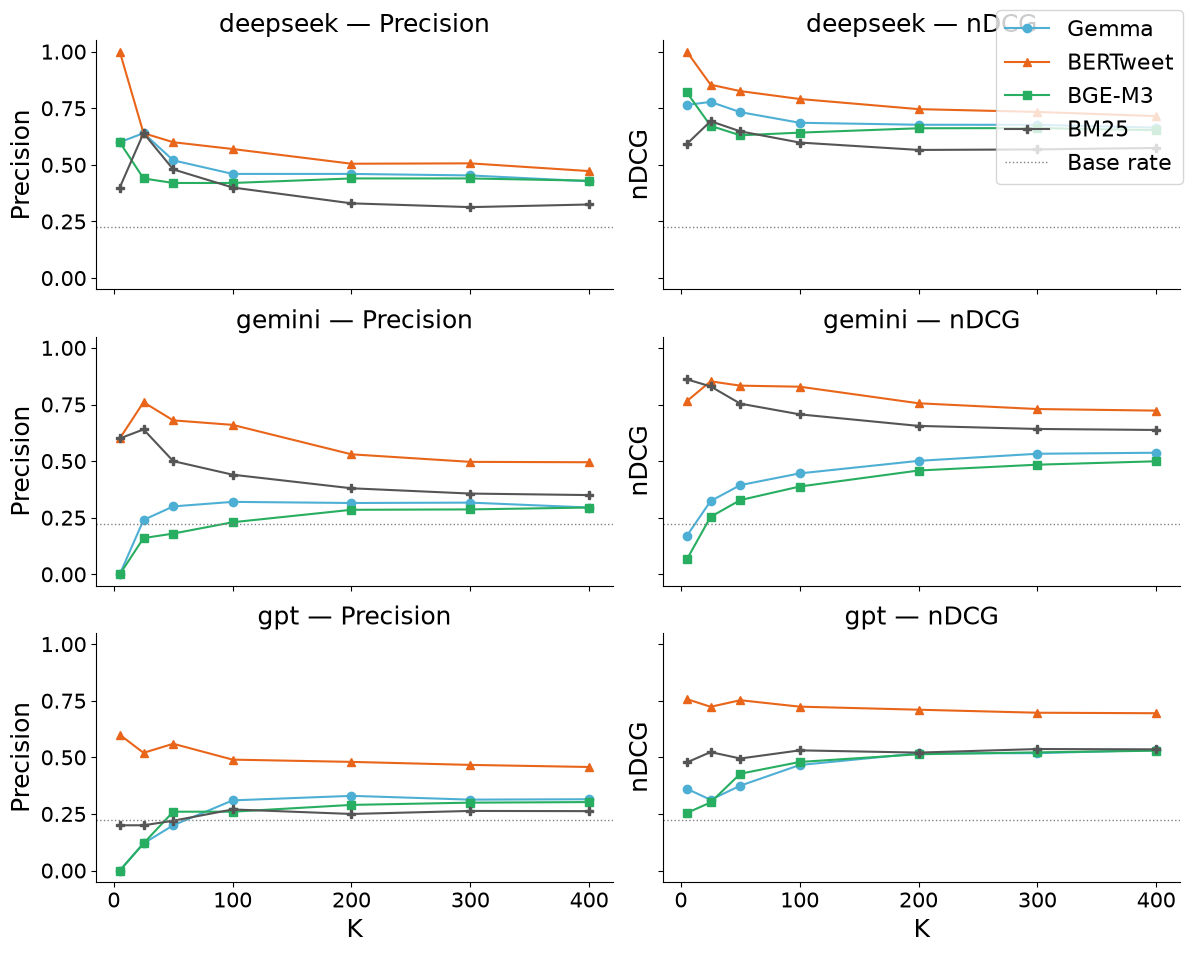

In [56]:
fig, axes = plt.subplots(
    len(LLM_NAMES), 2,
    figsize=(12, 3.2 * len(LLM_NAMES)),
    sharex=True, sharey=True
)

for row, llm in enumerate(LLM_NAMES):
    for col, (metric, ylabel) in enumerate([("Precision@K", "Precision"), ("nDCG@K", "nDCG")]):
        ax = axes[row][col]
        data = results_df[results_df["LLM"] == llm]

        for system, (color, marker, ls) in STYLES.items():
            s = data[data["System"] == system]
            if s.empty:
                continue
            ax.plot(s["K"], s[metric], color=color, marker=marker,
                    linestyle=ls, label=system, linewidth=1.5)

        ax.axhline(BASE_RATE, color="gray", linestyle=":", linewidth=1, label="Base rate")
        ax.set_ylabel(ylabel, fontsize=FONTSIZE_AXLABEL)
        ax.set_title(f"{llm} — {ylabel}", fontsize=FONTSIZE_TITLE)
        ax.tick_params(labelsize=FONTSIZE_TICK)
        sns.despine(ax=ax)

axes[-1][0].set_xlabel("K", fontsize=FONTSIZE_AXLABEL)
axes[-1][1].set_xlabel("K", fontsize=FONTSIZE_AXLABEL)
handles, labels = axes[0][0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper right", fontsize=FONTSIZE_LEGEND)
plt.tight_layout()
plt.show()

---
## 3. Qualitative Analysis — Inter-Annotator Agreement

Two human annotators evaluated the top-10 retrieved pairs per LLM per label (90 pairs total).  
Dimensions: lexical, tone, style, entity, narrative, overall — rated 1 (very similar) to 4 (very dissimilar).

In [57]:
df_ann = pd.read_csv("data/annotations/top_matches_annotations_merged.csv")

dims = ["lexical", "tone", "style", "entity", "narrative", "overall"]

for dim in dims:
    df_ann[f"{dim}_mean"] = df_ann[[f"{dim}_1", f"{dim}_2"]].mean(axis=1)

df_ann.head()

,Unnamed: 0,llm,llm_text,human_text,cosine_score,bertscore_score,label,llm_row_idx,lexical_1,tone_1,...,style_2,entity_2,narrative_2,overall_2,lexical_mean,tone_mean,style_mean,entity_mean,narrative_mean,overall_mean
0,0,deepseek,The CDC is lying about monkeypox transmission ...,CDC/ WHO swear on everything holy that monkeyp...,0.746128,0.814874,FALSE,99,2.0,2.0,...,2.0,1.0,3.0,2.0,2.0,2.0,2.0,1.0,2.0,2.0
1,1,deepseek,The WHO only declared monkeypox an emergency A...,The WHO Is About to Decide if #Monkeypox Has B...,0.685363,0.814562,TRUE,28,1.0,4.0,...,3.0,1.0,4.0,2.0,1.5,4.0,3.0,1.0,3.5,2.5
2,2,deepseek,So now they're telling us monkeypox is basical...,They said Monkeypox is airborne now?! Smh,0.742036,0.851209,FALSE,92,1.0,2.0,...,2.0,1.0,3.0,1.0,1.5,2.0,2.5,1.0,2.5,1.5
3,3,deepseek,The WHO just declared monkeypox a global emerg...,@WHO monkey pox is now spreading all over the ...,0.730042,0.832598,OTHER,24,2.0,2.0,...,2.0,1.0,2.0,2.0,2.5,1.5,2.0,1.0,2.0,2.0
4,4,deepseek,So now they're telling us monkeypox is basical...,@udell_cherise @Monkeypoxtally Not surprising ...,0.734252,0.808204,FALSE,92,3.0,2.0,...,3.0,3.0,3.0,2.0,2.5,2.0,2.5,2.5,2.0,2.0


In [58]:
print("=== INTER-ANNOTATOR AGREEMENT ===")
print("\n--- Overall ---")
for dim in dims:
    kappa = cohen_kappa_score(df_ann[f"{dim}_1"], df_ann[f"{dim}_2"], weights="quadratic")
    data  = np.array([df_ann[f"{dim}_1"].values, df_ann[f"{dim}_2"].values], dtype=float)
    alpha = krippendorff.alpha(reliability_data=data, level_of_measurement="ordinal")
    print(f"  {dim:<12}  kappa={kappa:.3f}  alpha={alpha:.3f}")

for label in ["FALSE", "TRUE", "OTHER"]:
    df_l = df_ann[df_ann["label"] == label]
    print(f"\n--- {label} (n={len(df_l)}) ---")
    for dim in dims:
        kappa = cohen_kappa_score(df_l[f"{dim}_1"], df_l[f"{dim}_2"], weights="quadratic")
        print(f"  {dim:<12}  kappa={kappa:.3f}")

=== INTER-ANNOTATOR AGREEMENT ===

--- Overall ---
  lexical       kappa=0.216  alpha=0.189
  tone          kappa=0.547  alpha=0.544
  style         kappa=0.192  alpha=0.089
  entity        kappa=0.197  alpha=0.233
  narrative     kappa=0.530  alpha=0.522
  overall       kappa=0.213  alpha=0.129

--- FALSE (n=30) ---
  lexical       kappa=0.140
  tone          kappa=0.649
  style         kappa=0.427
  entity        kappa=0.120
  narrative     kappa=0.540
  overall       kappa=0.195

--- TRUE (n=30) ---
  lexical       kappa=0.067
  tone          kappa=0.239
  style         kappa=0.182
  entity        kappa=0.248
  narrative     kappa=0.552
  overall       kappa=0.234

--- OTHER (n=30) ---
  lexical       kappa=0.186
  tone          kappa=0.258
  style         kappa=0.019
  entity        kappa=0.118
  narrative     kappa=0.396
  overall       kappa=0.074


In [59]:
print("=== MEAN SIMILARITY SCORES ===")
for label in sorted(df_ann["label"].unique()):
    df_l = df_ann[df_ann["label"] == label]
    print(f"\n--- {label} ---")
    for dim in dims:
        m = df_l[f"{dim}_mean"].mean()
        s = df_l[f"{dim}_mean"].std()
        print(f"  {dim:<12}  {m:.2f} ± {s:.2f}")

=== MEAN SIMILARITY SCORES ===

--- FALSE ---
  lexical       2.65 ± 0.60
  tone          2.33 ± 0.80
  style         3.05 ± 0.70
  entity        1.53 ± 0.49
  narrative     2.45 ± 0.95
  overall       2.12 ± 0.57

--- OTHER ---
  lexical       2.60 ± 0.53
  tone          2.02 ± 0.55
  style         2.72 ± 0.55
  entity        1.23 ± 0.31
  narrative     2.33 ± 0.84
  overall       1.98 ± 0.52

--- TRUE ---
  lexical       2.07 ± 0.45
  tone          3.10 ± 0.65
  style         2.93 ± 0.64
  entity        1.42 ± 0.49
  narrative     3.02 ± 0.90
  overall       2.45 ± 0.63


In [60]:
for llm in LLM_NAMES:
    df_model = df_ann[df_ann["llm"] == llm]
    best  = df_model.loc[df_model["cosine_score"].idxmax()]
    worst = df_model.loc[df_model["cosine_score"].idxmin()]

    print(f"\n=== {llm.upper()} ===")
    print(f"BEST  | label={best['label']} | cosine={best['cosine_score']:.3f} | overall={best['overall_mean']:.2f}")
    print(f"  LLM: {best['llm_text']}")
    print(f"  HUM: {best['human_text']}")
    print(f"WORST | label={worst['label']} | cosine={worst['cosine_score']:.3f} | overall={worst['overall_mean']:.2f}")
    print(f"  LLM: {worst['llm_text']}")
    print(f"  HUM: {worst['human_text']}")


=== DEEPSEEK ===
BEST  | label=OTHER | cosine=0.764 | overall=2.00
  LLM: The WHO just declared monkeypox a global emergency, but they're still letting infected travelers roam freely. This is a deliberate failure to protect us. They care more about political correctness than public health.
  HUM: @WHO monkey pox is now spreading all over the world. Why do you even exist as an organization when you fail to take action to protect the GLOBAL community? This is the second pandemic you dragged you feet on declaring it an emergency. New leadership is in order!
WORST | label=TRUE | cosine=0.676 | overall=3.00
  LLM: The WHO only declared monkeypox a global emergency because it's spreading in Europe. If this was still primarily affecting African nations, they'd have ignored it like they always do. Their concern is selective and racist.
  HUM: Monkeypox is not a global health emergency for now, WHO says? _URL_

=== GEMINI ===
BEST  | label=OTHER | cosine=0.820 | overall=1.50
  LLM: The WHO is 